# Cross-Crop Endogenous Correlation Blocks

This notebook draws correlation heatmaps where each crop is used as a reference block. For example, for wheat it correlates `corn_{weekly,monthly,seasonal}_rv` and `soybeans_{weekly,monthly,seasonal}_rv` against all wheat endogenous features. The same pattern is repeated for corn and soybeans.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.util.path import DATA_DIR

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

In [2]:
# Configure the dataset and crop order.
DATA_PATH = DATA_DIR / 'ag' / 'v6.csv'
CROPS = ('wheat', 'corn', 'soybeans')
TARGET_SUFFIXES = ('weekly_rv', 'monthly_rv', 'seasonal_rv')
ENDO_METRICS = ('rv', 'rvb', 'rvg', 'jumps')
METHOD = 'pearson'
DROP_MISSING = True

In [3]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(832, 93)


,date,corn_weekly_rv,corn_weekly_rvg,corn_weekly_rvb,corn_weekly_rsk,corn_weekly_rku,corn_weekly_jumps,corn_weekly_tru,corn_weekly_trd,corn_weekly_lev,...,ssta_lanina,SOI_index,NAO_index,DJIA_Index,WTI_Index,Broad_Dollar_index,Text_Climate_Anomaly,Stock_Uncertainty,frbsf_sentiment,epu_index
0,2009-04-13,0.014740,0.009140,0.011311,-1.059369,12.520426,0.000039,0.000065,0.000103,-0.212748,...,0.0,0.530000,0.364000,NaN,3.911023,100.1369,-0.022368,170.870000,-0.225714,117.434286
1,2009-04-20,0.015534,0.010501,0.011049,-0.119789,12.957318,0.000047,0.000102,0.000097,-0.087395,...,0.0,0.320000,0.802667,8.996688,3.818152,101.4480,0.186285,51.764286,-0.235714,127.531429
2,2009-04-27,0.020031,0.014932,0.013110,0.887230,12.171946,0.000088,0.000187,0.000121,0.129211,...,0.0,0.110000,1.241333,9.013402,3.914221,100.7258,0.615175,58.567143,-0.255714,170.924286
3,2009-05-04,0.019517,0.015243,0.011858,1.633651,17.233828,0.000054,0.000198,0.000107,0.228647,...,0.0,-0.068756,1.546378,9.056565,3.998384,99.1340,0.257109,57.110000,-0.237143,143.804286
4,2009-05-11,0.016296,0.010815,0.011872,-0.590406,13.131681,0.000023,0.000080,0.000136,-0.057299,...,0.0,-0.054839,1.027419,9.020225,4.062682,97.7470,0.107827,28.824286,-0.248571,117.497143


In [4]:
def endogenous_columns(frame: pd.DataFrame, crop: str, metrics: tuple[str, ...]) -> list[str]:
    prefix = f'{crop}_'
    selected = []
    for column in frame.columns:
        if not column.startswith(prefix):
            continue
        parts = column.split('_')
        if len(parts) < 3:
            continue
        if parts[-1] in metrics:
            selected.append(column)
    return selected


def core_rv_columns(frame: pd.DataFrame, crop: str, suffixes: tuple[str, ...]) -> list[str]:
    selected = []
    for suffix in suffixes:
        column = f'{crop}_{suffix}'
        if column in frame.columns:
            selected.append(column)
    return selected


crop_feature_map = {crop: endogenous_columns(df, crop, ENDO_METRICS) for crop in CROPS}
crop_core_map = {crop: core_rv_columns(df, crop, TARGET_SUFFIXES) for crop in CROPS}

for crop in CROPS:
    print(
        f"{crop}: {len(crop_feature_map[crop])} filtered endogenous features, core RV columns = {crop_core_map[crop]}"
    )

wheat: 12 filtered endogenous features, core RV columns = ['wheat_weekly_rv', 'wheat_monthly_rv', 'wheat_seasonal_rv']
corn: 12 filtered endogenous features, core RV columns = ['corn_weekly_rv', 'corn_monthly_rv', 'corn_seasonal_rv']
soybeans: 12 filtered endogenous features, core RV columns = ['soybeans_weekly_rv', 'soybeans_monthly_rv', 'soybeans_seasonal_rv']


In [5]:
selected_columns = sorted({column for columns in crop_feature_map.values() for column in columns})
work_df = df[selected_columns].copy()
work_df = work_df.apply(pd.to_numeric, errors='coerce')

if DROP_MISSING:
    work_df = work_df.dropna()
else:
    work_df = work_df.fillna(work_df.mean(numeric_only=True))

corr = work_df.corr(method=METHOD)
corr.head()

,corn_monthly_jumps,corn_monthly_rv,corn_monthly_rvb,corn_monthly_rvg,corn_seasonal_jumps,corn_seasonal_rv,corn_seasonal_rvb,corn_seasonal_rvg,corn_weekly_jumps,corn_weekly_rv,...,wheat_monthly_rvb,wheat_monthly_rvg,wheat_seasonal_jumps,wheat_seasonal_rv,wheat_seasonal_rvb,wheat_seasonal_rvg,wheat_weekly_jumps,wheat_weekly_rv,wheat_weekly_rvb,wheat_weekly_rvg
corn_monthly_jumps,1.000000,0.672863,0.662037,0.641708,0.676079,0.534911,0.540798,0.514453,0.143469,0.411191,...,0.313401,0.295862,0.254281,0.230474,0.240760,0.211717,0.134113,0.212290,0.195425,0.219133
corn_monthly_rv,0.672863,1.000000,0.989666,0.988447,0.649287,0.838973,0.836381,0.833551,0.253909,0.704413,...,0.713224,0.705198,0.561556,0.601302,0.601752,0.588257,0.313053,0.541518,0.529149,0.529055
corn_monthly_rvb,0.662037,0.989666,1.000000,0.957667,0.632471,0.823487,0.827729,0.811509,0.262491,0.700459,...,0.720227,0.693241,0.556104,0.598231,0.602163,0.581607,0.321198,0.544856,0.532200,0.532263
corn_monthly_rvg,0.641708,0.988447,0.957667,1.000000,0.642466,0.839227,0.829592,0.841659,0.242403,0.695100,...,0.699296,0.712442,0.559700,0.599654,0.595718,0.591625,0.303027,0.535690,0.524258,0.522899
corn_seasonal_jumps,0.676079,0.649287,0.632471,0.642466,1.000000,0.787347,0.787865,0.766672,0.156328,0.411774,...,0.261491,0.267929,0.400687,0.341164,0.344341,0.325964,0.116248,0.146492,0.129413,0.153889


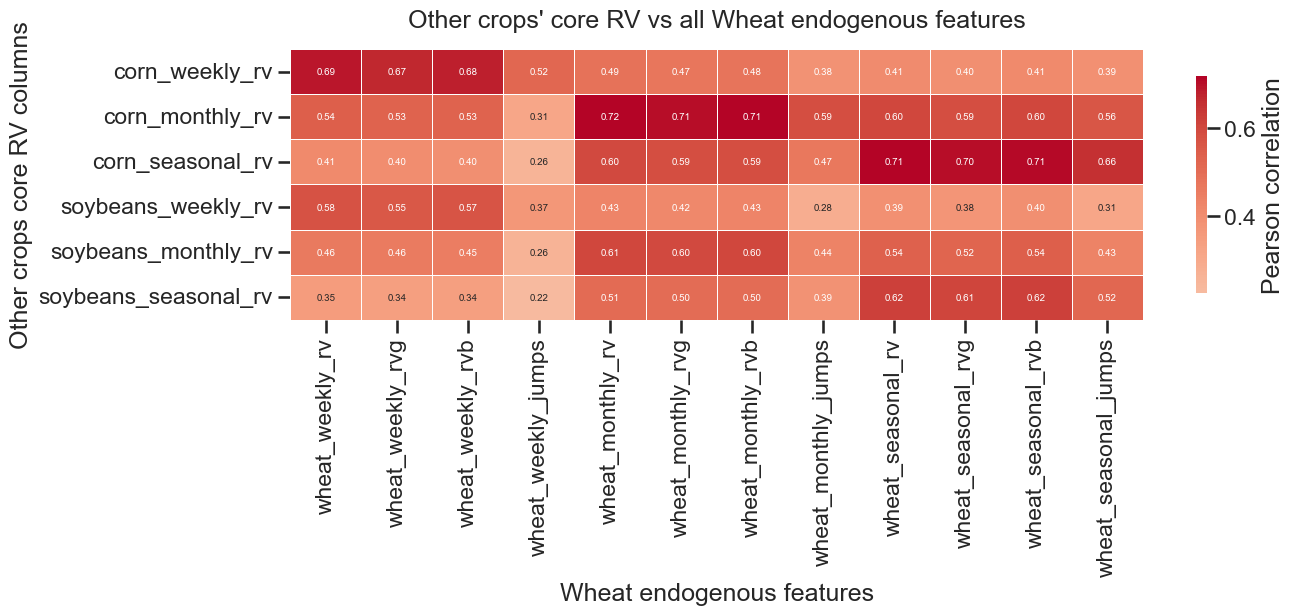

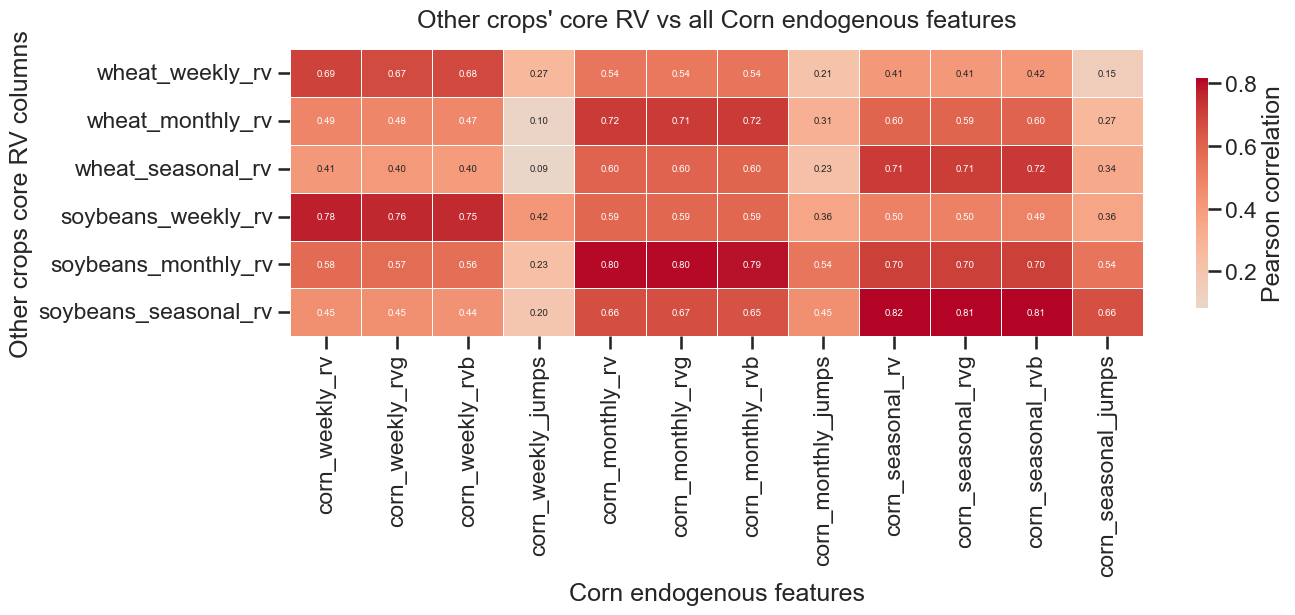

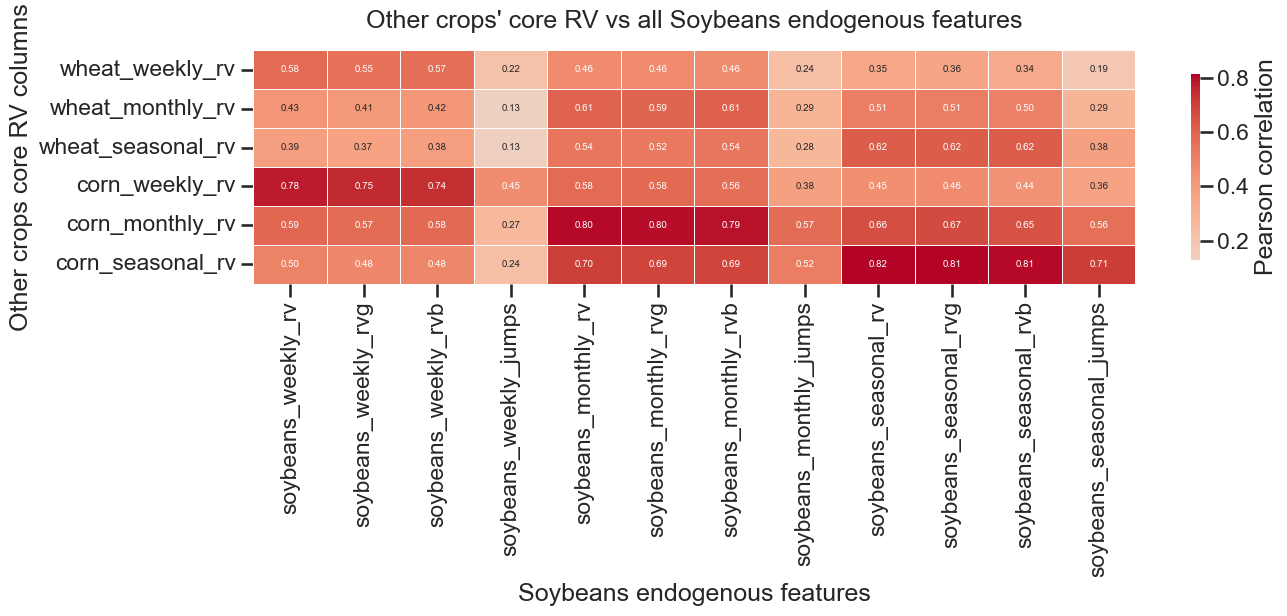

In [6]:
for reference_crop in CROPS:
    reference_features = crop_feature_map[reference_crop]
    other_core_rows = []
    for other_crop in CROPS:
        if other_crop == reference_crop:
            continue
        other_core_rows.extend(crop_core_map[other_crop])
    block = corr.loc[other_core_rows, reference_features]
    fig_width = max(14, 0.32 * len(reference_features) + 4)
    fig_height = max(5, 0.75 * len(other_core_rows) + 2)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    sns.heatmap(
        block,
        cmap='coolwarm',
        center=0,
        linewidths=0.5,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 7},
        cbar_kws={'shrink': 0.8, 'label': f'{METHOD.title()} correlation'},
        ax=ax,
    )
    ax.set_title(
        f"Other crops' core RV vs all {reference_crop.title()} endogenous features",
        pad=16,
    )
    ax.set_xlabel(f'{reference_crop.title()} endogenous features')
    ax.set_ylabel('Other crops core RV columns')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()

## Notes

- For `reference_crop = 'wheat'`, rows are `corn_weekly_rv`, `corn_monthly_rv`, `corn_seasonal_rv`, `soybeans_weekly_rv`, `soybeans_monthly_rv`, and `soybeans_seasonal_rv`.
- Columns are filtered endogenous features of the reference crop, limited to `rv`, `rvb`, `rvg`, and `jumps`.
- The notebook repeats the same pattern for `corn` and `soybeans`.
- This keeps the rows limited to the three core RV horizons of the other crops, while the columns include only the selected endogenous metrics of the reference crop.
- Metrics such as `rsk`, `rku`, `tru`, `trd`, and `lev` are excluded.

## Within-Crop Endogenous Correlation Matrices

This section plots a full endogenous-vs-endogenous correlation matrix for each crop separately, filtered to `rv`, `rvb`, `rvg`, and `jumps` only.

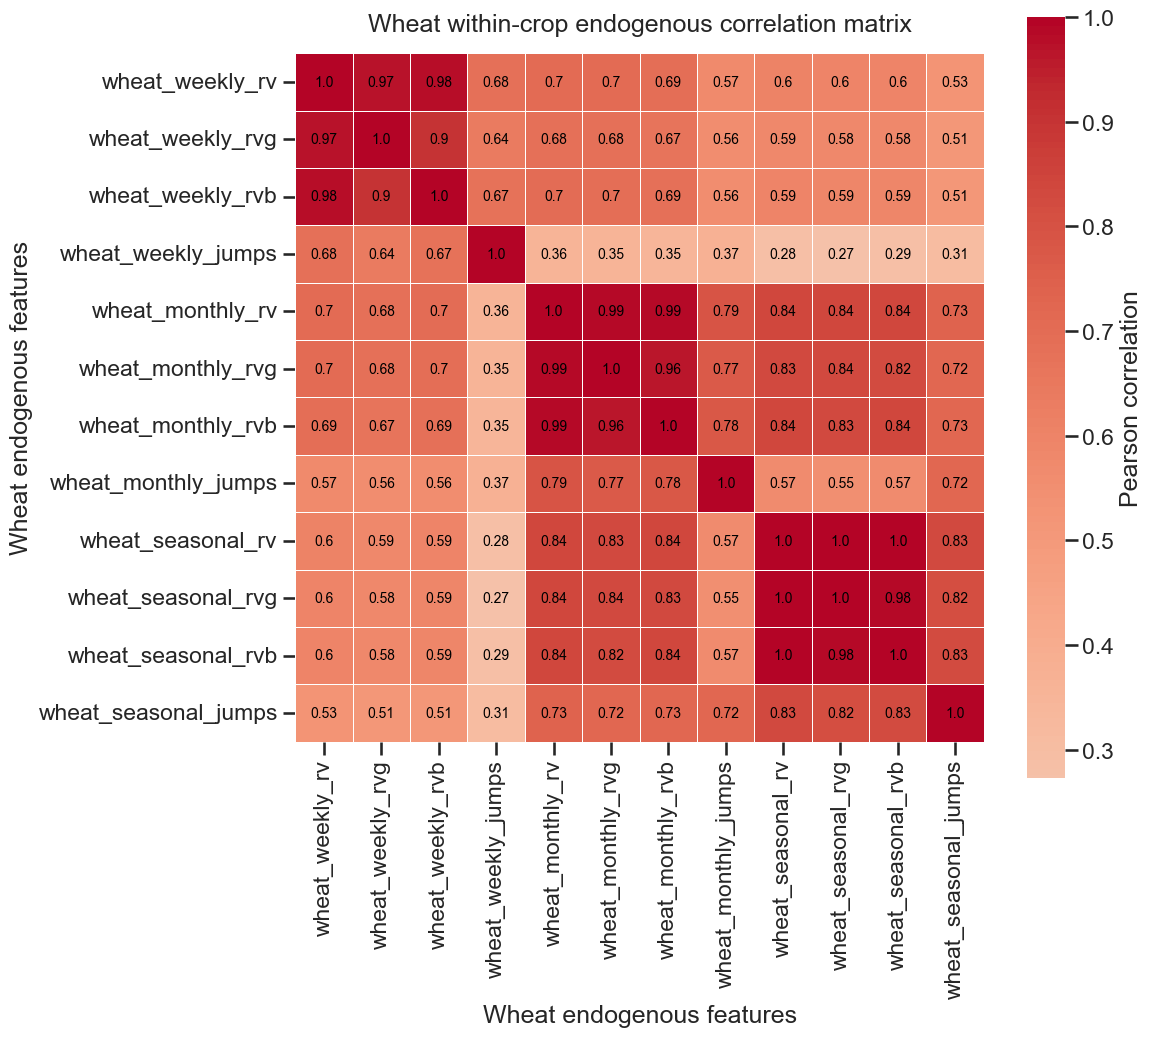

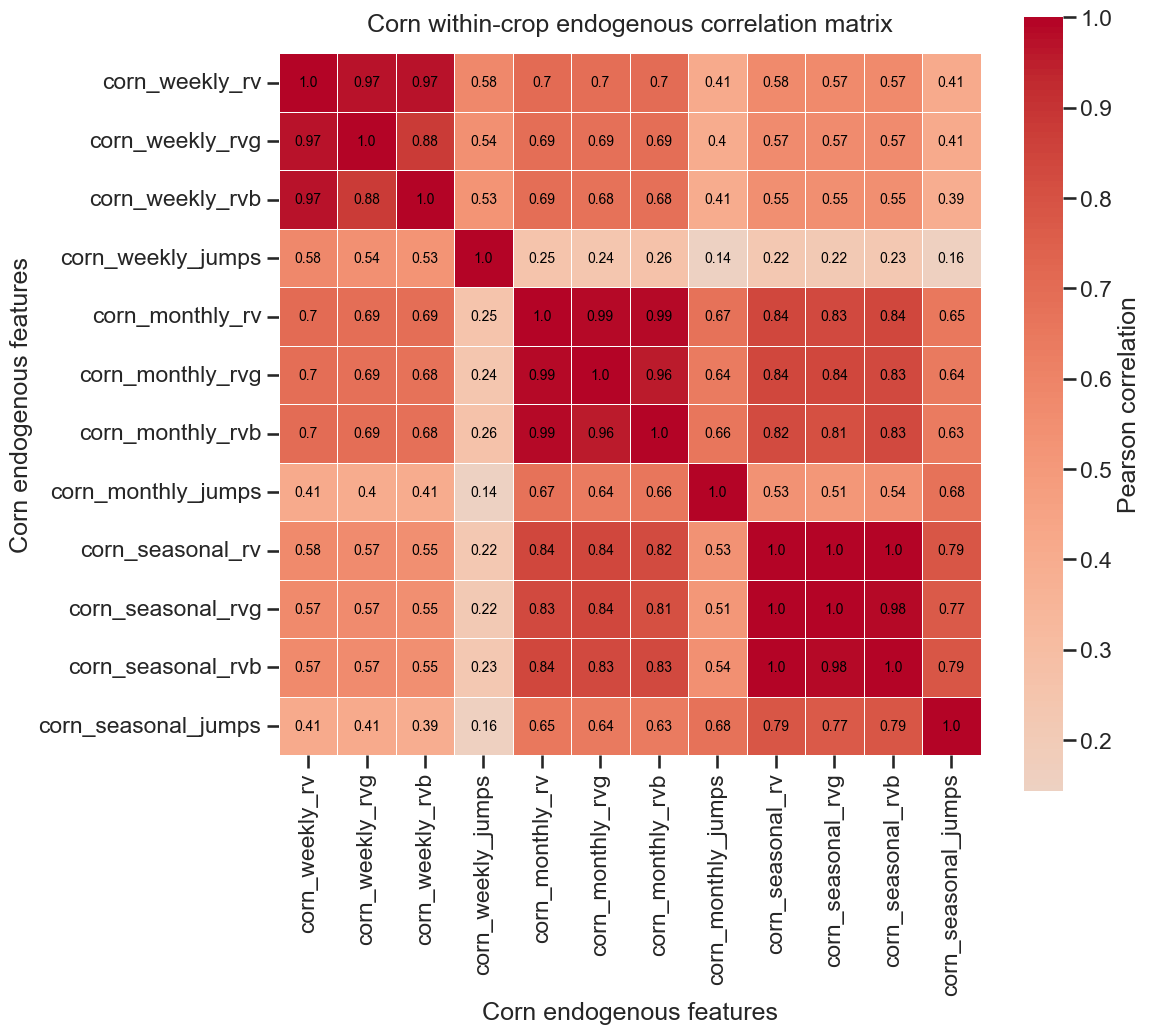

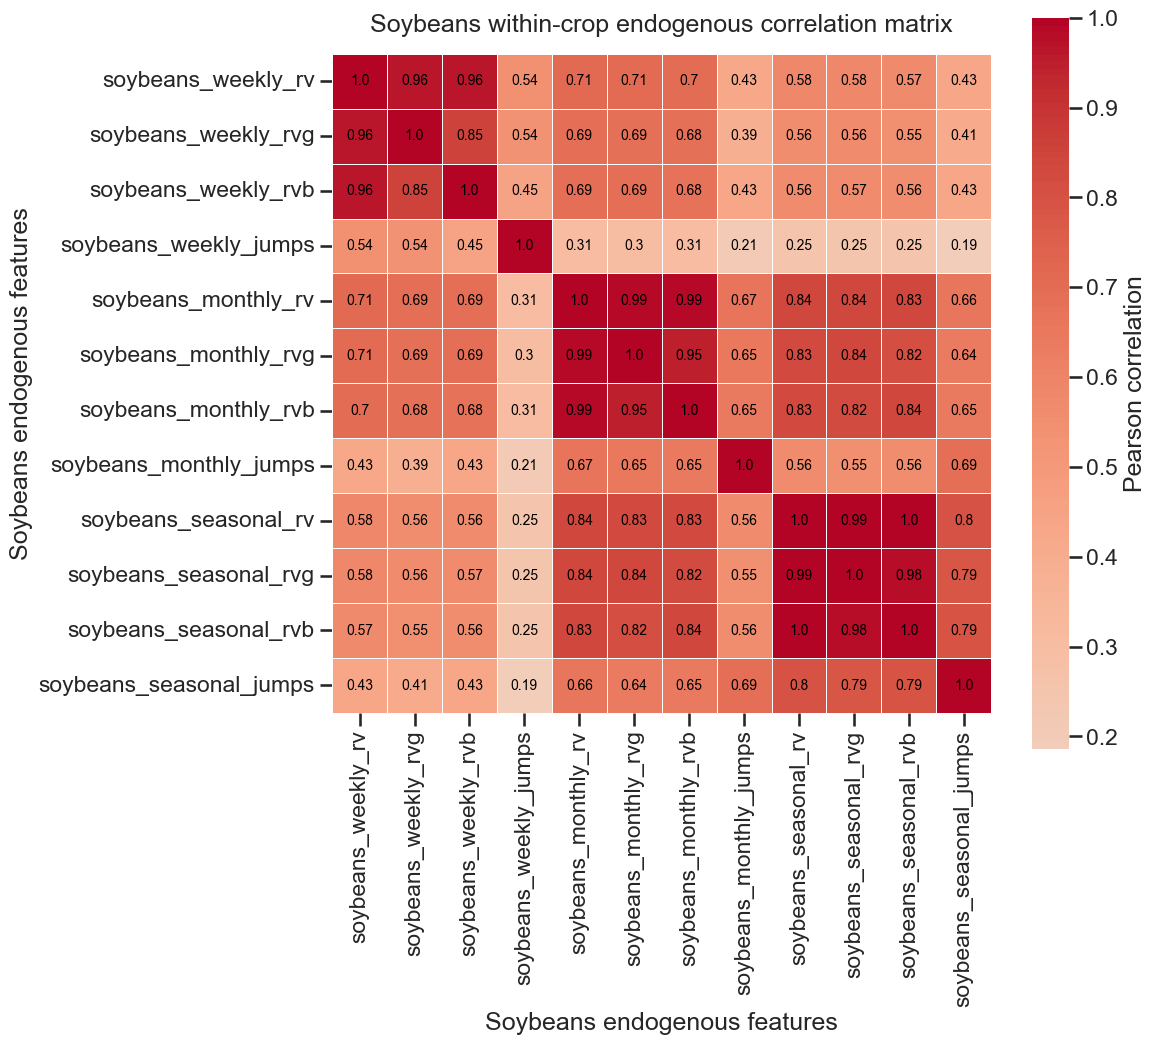

In [7]:
for crop in CROPS:
    crop_features = crop_feature_map[crop]
    crop_block = corr.loc[crop_features, crop_features]
    annotation_labels = crop_block.round(2).astype(str)

    n_features = max(len(crop_features), 1)
    fig_size = max(12, 0.5 * n_features + 2)
    font_size = max(6, min(10, int(220 / n_features)))

    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    sns.heatmap(
        crop_block,
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=0.5,
        annot=annotation_labels,
        fmt='',
        annot_kws={'size': font_size, 'color': 'black'},
        cbar_kws={'shrink': 0.8, 'label': f'{METHOD.title()} correlation'},
        ax=ax,
    )
    ax.set_title(f'{crop.title()} within-crop endogenous correlation matrix', pad=16)
    ax.set_xlabel(f'{crop.title()} endogenous features')
    ax.set_ylabel(f'{crop.title()} endogenous features')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()